In [2]:
import json
import numpy as np
%matplotlib ipympl
import matplotlib.pyplot as plt
import datetime
import pandas as pd
import re

In [ ]:
file_list = [r"..\save_for_later\hourly_mpp_interpolation_circular_polysolar_kent_0_to_24_1x4.json",
             r"..\save_for_later\hourly_mpp_interpolation_circular_polysolar_kent_0_to_24_2x2.json",
             r"..\save_for_later\hourly_mpp_interpolation_circular_polysolar_kent_0_to_24_2x4.json",]
#file_list = [
             #r"outputs\hourly_mpp_interpolation_circular_polysolar_kent_8016_to_8760.json",
             #r"validation_file_hourly_december_data_martyn.csv_8023_8753.json",
             #r"../save_for_later/validation_file_hourly_december_data_martyn.csv_8023_8753.json",
            #  r"outputs\hourly_mpp_interpolation_circular_polysolar_kent_0_to_120.json",
            #  r"..\save_for_later\hourly_mpp_interpolation_circular_polysolar_kent_0_to_120.json",
             
            
            # r"outputs\hourly_mpp_circular_polysolar_kent_2616_to_2640.json",
            # r"outputs\hourly_mpp_circular_polysolar_kent_bypassed_2_2616_to_2640.json",
            # r"outputs\hourly_mpp_circular_polysolar_kent_bypassed_10_2616_to_2640.json",
            # r"outputs\hourly_mpp_interpolation_circular_polysolar_kent_2616_to_2640.json",
            # r"outputs\hourly_mpp_interpolation_circular_polysolar_kent_bypassed_2_2616_to_2640.json",
            # r"outputs\hourly_mpp_interpolation_circular_polysolar_kent_bypassed_10_2616_to_2640.json",
            # r"..\save_for_later\hourly_mpp_interpolation_circular_polysolar_kent_2616_to_2640.json",
            # r"..\save_for_later\hourly_mpp_interpolation_circular_polysolar_kent_bypassed_2_2616_to_2640.json",
            # r"..\save_for_later\hourly_mpp_interpolation_circular_polysolar_kent_bypassed_10_2616_to_2640.json",
#            ]

In [ ]:
interpolation_find_pattern = r"outputs\\hourly_mpp_([^/]+)_circular_polysolar_kent"
bypass_find_pattern = r"circular_polysolar_kent_([^/]+)_2616_to_2640.json"
other_pattern = r"..\\([^/]+)\\hourly"
panel_setup_pattern = r"circular_polysolar_kent_[^/]+.json_([^/]+)"

In [1]:
def extract_part(file_path, pattern):
    match = re.search(pattern, file_path)
    return match.group(1) if match else None

def load_json_to_dataframe(file_path):
    with open(file_path) as f:
        hourly_data = json.load(f)
        data_dict = {}
        method = extract_part(file_path, interpolation_find_pattern)
        system = extract_part(file_path, panel_setup_pattern)
        if method == None:
            method = extract_part(file_path, other_pattern)
        for i,val in enumerate(hourly_data):
            date_obj = datetime.datetime.strptime(val[0] + f' {val[1]}','%d/%m/%Y %H')
            mpp = val[2]
        
            data_dict[date_obj] = [mpp,method,system]
        
        df = pd.DataFrame.from_dict(data_dict, orient='index',columns=['MPP (W)', 'Method','System'])
    
    return df

In [4]:
df_dict = {}
for file in file_list:
    df_dict[file] = load_json_to_dataframe(file)

FileNotFoundError: [Errno 2] No such file or directory: '..\\save_for_later\\hourly_mpp_interpolation_circular_polysolar_kent_0_to_24.json_1x4'

In [36]:
print(df_dict[file_list[0]].head())

                       MPP (W) Method
2023-12-01 07:00:00   0.000000   None
2023-12-01 08:00:00   0.000000   None
2023-12-01 09:00:00   7.517697   None
2023-12-01 10:00:00  24.942093   None
2023-12-01 11:00:00  40.853795   None


In [8]:
df = pd.DataFrame.from_dict(data_dict, orient='index',columns=['MPP (W)', 'Method'])
by_day = df.groupby(df.index.to_series().dt.date).sum().rename(columns={'MPP (W)':'Daily Generation (kWh)'})/1000
by_month = df.groupby(df.index.to_series().dt.month).sum().rename(columns={'MPP (W)':'Monthly Generation (kWh)'})/1000
peak_by_day = df.groupby(df.index.to_series().dt.date).max().rename(columns={'MPP (W)':'Peak power (Wp)'})

NameError: name 'data_dict' is not defined

In [21]:
total_production = df.sum().to_numpy()[0]
system_peak = 1*280
solar_yield = total_production/system_peak
print(f'Total production: {total_production/1000:.0f} kWh, Solar yield: {solar_yield:.0f} kWh/kWp')

Total production: 0 kWh, Solar yield: 0 kWh/kWp


In [7]:
plt.close('all')

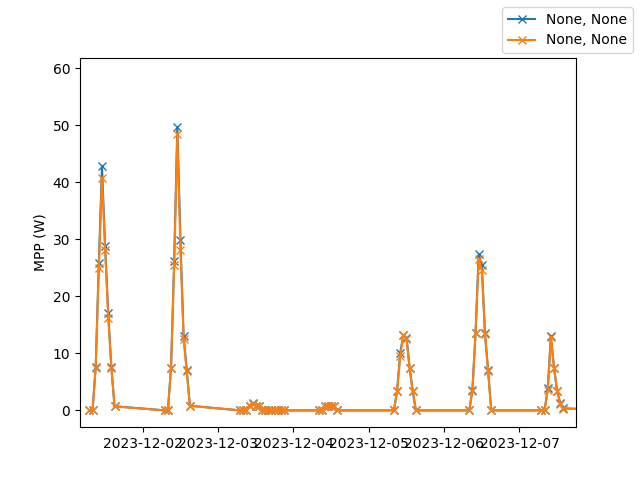

In [51]:
fig,ax = plt.subplots()
for filename,df in df_dict.items():
    ax.plot(df.index,df[df.columns[0]],
            label=f"{df['Method'].iloc[0]}, {extract_part(filename,bypass_find_pattern)}",
            marker = 'x')
    ax.set_ylabel(df.columns[0])

ax.set_xlim(datetime.datetime(2023,12,1,4),datetime.datetime(2023,12,7,18))
#ax.set_xlim(datetime.datetime(2023,4,20,4),datetime.datetime(2023,4,20,18))
fig.legend()
plt.show()

### Single File Reader